In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
cpu_df = pd.read_csv(
    "../data/Processed/cpu_master_new.csv"
)

In [3]:
# convert timestamp
cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)

In [4]:
cpu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6372 entries, 0 to 6371
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   id                6372 non-null   int64              
 1   ts                6372 non-null   datetime64[ns, UTC]
 2   host_id           6372 non-null   int64              
 3   cpu_usage_pct     6372 non-null   float64            
 4   memory_usage_pct  6372 non-null   float64            
 5   power_kw          6372 non-null   float64            
 6   temperature_c     6372 non-null   int64              
 7   status            6372 non-null   object             
 8   hostName          6372 non-null   object             
 9   ilo_server_id     6372 non-null   int64              
 10  inlet_temp_c      6372 non-null   int64              
 11  cpu_temp_c        6372 non-null   int64              
 12  processor_count   6372 non-null   int64              
dtypes: 

In [5]:
# missing values analysis
cpu_df.isnull().sum()

id                  0
ts                  0
host_id             0
cpu_usage_pct       0
memory_usage_pct    0
power_kw            0
temperature_c       0
status              0
hostName            0
ilo_server_id       0
inlet_temp_c        0
cpu_temp_c          0
processor_count     0
dtype: int64

In [6]:
# duplicate check
cpu_df.duplicated().sum()

np.int64(0)

In [7]:
# Status distribution
cpu_df["status"].value_counts()

status
Normal     6008
Warning     364
Name: count, dtype: int64

In [8]:
cpu_df["status_encoded"] = (
    cpu_df["status"]
    .map({
        "Normal":0,
        "Warning":1,
        "Critical":2
    })
)

cpu_df.head()

,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,temperature_c,status,hostName,ilo_server_id,inlet_temp_c,cpu_temp_c,processor_count,status_encoded
0,74125,2026-06-11 00:01:37.268000+00:00,1,2.03,81.65,0.220,27,Warning,10.10.10.65,1,27,41,2,1
1,74128,2026-06-11 00:06:36.561000+00:00,1,2.03,81.65,0.221,28,Warning,10.10.10.65,1,28,43,2,1
2,74131,2026-06-11 00:11:42.330000+00:00,1,1.88,81.65,0.220,23,Warning,10.10.10.65,1,23,41,2,1
3,74134,2026-06-11 00:16:37.251000+00:00,1,2.78,81.65,0.221,20,Warning,10.10.10.65,1,20,39,2,1
4,74137,2026-06-11 00:21:36.482000+00:00,1,3.31,81.65,0.220,25,Warning,10.10.10.65,1,25,40,2,1


In [9]:
# timestamp storing
cpu_df = cpu_df.sort_values(
    ["hostName","ts"]
)
# reset index
cpu_df = cpu_df.reset_index(drop=True)

In [10]:
# Check CPU range
cpu_df["cpu_usage_pct"].describe()

count    6372.000000
mean       11.457611
std        11.967621
min         1.010000
25%         2.140000
50%         3.755000
75%        27.220000
max        40.190000
Name: cpu_usage_pct, dtype: float64

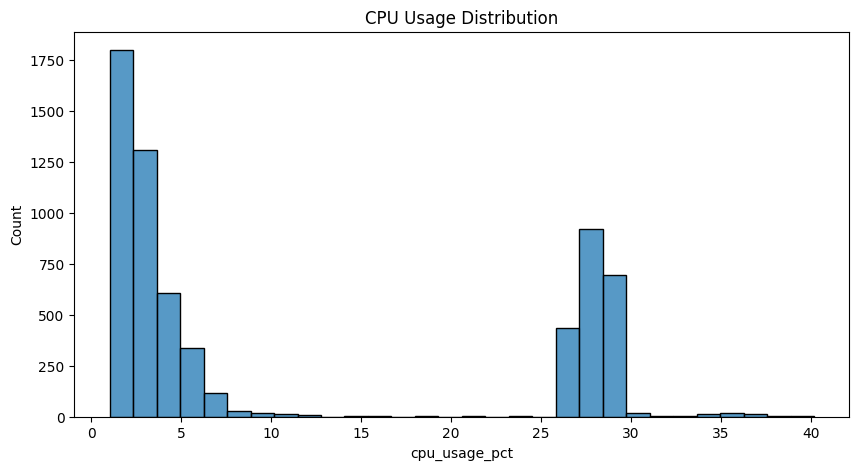

In [11]:
# CPU distribution plot
plt.figure(figsize=(10,5))

sns.histplot(
    cpu_df["cpu_usage_pct"],
    bins=30
)

plt.title("CPU Usage Distribution")
plt.show()

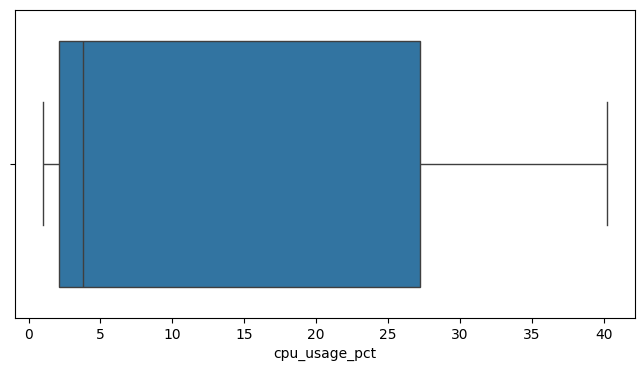

In [12]:
# Boxplot
plt.figure(figsize=(8,4))

sns.boxplot(
    x=cpu_df["cpu_usage_pct"]
)

plt.show()

In [13]:
# Outlier detection
Q1 = cpu_df["cpu_usage_pct"].quantile(0.25)

Q3 = cpu_df["cpu_usage_pct"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-35.48
64.84


In [14]:
# Count outliers
outliers = cpu_df[
    (cpu_df["cpu_usage_pct"] < lower)
    |
    (cpu_df["cpu_usage_pct"] > upper)
]

print(len(outliers))

0


In [15]:
# Check sampling interval
genai = cpu_df[
    cpu_df["hostName"] ==
    cpu_df["hostName"].unique()[0]
]

# calculate interval
genai["ts"].diff().value_counts()

ts
0 days 00:05:00.025000    5
0 days 00:05:00.077000    4
0 days 00:04:59.873000    4
0 days 00:04:59.975000    4
0 days 00:05:00.043000    4
                         ..
0 days 00:04:59.973000    1
0 days 00:04:59.862000    1
0 days 00:04:57.148000    1
0 days 00:05:01.379000    1
0 days 00:05:02.554000    1
Name: count, Length: 1793, dtype: int64

In [16]:
genai["ts"].diff().describe()

count                         2123
mean     0 days 00:05:00.004037211
std      0 days 00:00:03.067739672
min         0 days 00:04:42.520000
25%         0 days 00:04:58.710500
50%         0 days 00:05:00.016000
75%         0 days 00:05:01.297000
max         0 days 00:05:17.565000
Name: ts, dtype: object

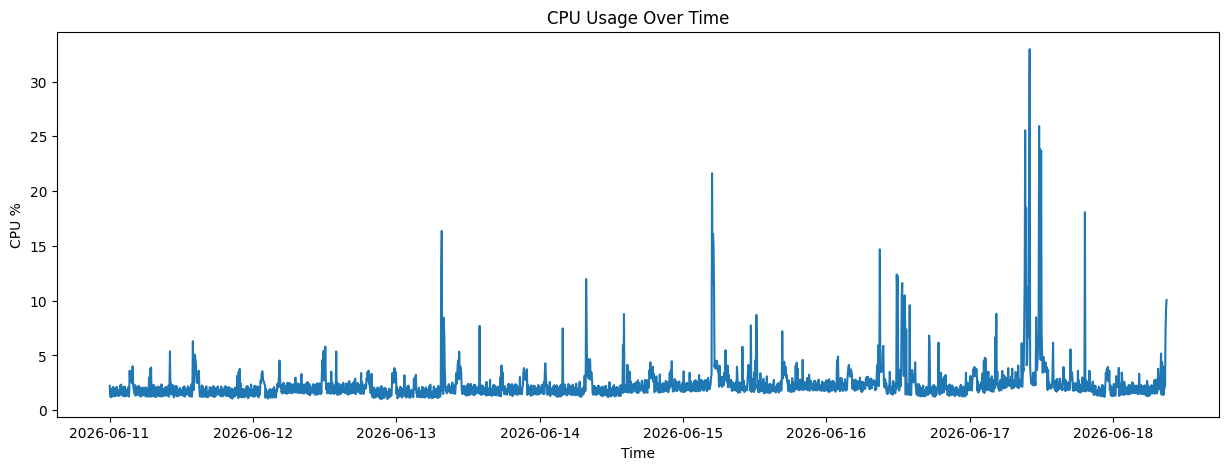

In [17]:
# Visualize CPU trends
plt.figure(figsize=(15,5))

plt.plot(
    genai["ts"],
    genai["cpu_usage_pct"]
)

plt.title("CPU Usage Over Time")
plt.xlabel("Time")
plt.ylabel("CPU %")

plt.show()

In [18]:
# server wise count
cpu_df.groupby(
    "hostName"
)["cpu_usage_pct"].count()

hostName
10.10.10.150    2124
10.10.10.2      2124
10.10.10.65     2124
Name: cpu_usage_pct, dtype: int64

In [19]:
cpu_cleaned_new = cpu_df.copy()

cpu_cleaned = cpu_cleaned_new.drop(
    columns=["ilo_server_id"]
)

In [20]:
cpu_cleaned.to_csv(
    "../data/Processed/cpu_cleaned_new.csv",
    index=False
)

In [21]:
cpu_cleaned_new.columns

Index(['id', 'ts', 'host_id', 'cpu_usage_pct', 'memory_usage_pct', 'power_kw',
       'temperature_c', 'status', 'hostName', 'ilo_server_id', 'inlet_temp_c',
       'cpu_temp_c', 'processor_count', 'status_encoded'],
      dtype='object')

In [22]:
# average cpu usage per server
avg_cpu = (
    cpu_df.groupby(["host_id", "hostName"])["cpu_usage_pct"]
    .mean()
    .reset_index()
)

avg_cpu["cpu_usage_pct"] = avg_cpu["cpu_usage_pct"].round(2)

print("Average CPU Usage Per Server")
print("-" * 50)

for _, row in avg_cpu.iterrows():
    print(
        f"Host ID   : {row['host_id']}\n"
        f"Host Name : {row['hostName']}\n"
        f"Average CPU Usage : {row['cpu_usage_pct']}%\n"    
    )

Average CPU Usage Per Server
--------------------------------------------------
Host ID   : 1
Host Name : 10.10.10.65
Average CPU Usage : 3.81%

Host ID   : 2
Host Name : 10.10.10.150
Average CPU Usage : 2.37%

Host ID   : 3
Host Name : 10.10.10.2
Average CPU Usage : 28.19%

